# DEF-D Fysieke Ontwerpopdracht 4 invul template
Aan het einde van deze ontwerpopdracht lever je als groep één gezamenlijk notebook in. Zet jullie groepsnummer, studienummers en namen in onderstaande tabel zodat wij zeker weten dat het groepsvormen goed is gegaan.

| Groep: 17     |  |
| :-------------|:-------------|
| Sam Lindner| 6391214 |
| Cedric Peignier| 6577458 |
| Eline Serpenti| 6506690 |

In [1]:
# Vul ook hieronder jullie voornamen in en run deze cel.
# Dat is nodig voor de code die je verderop in dit notebook gaat runnen.

studentNames = ['Sam', 'Cedric','Eline']

## Opdracht 1: Planning.

| Planning Groep: 17     |Tijdstip / Tijdspanne  |
|---|---|
| Kalibreren sensor | 12:00 |
| Ontwerpen algoritme | 14:00 |
| Itereren | 15:00 |
| groep aanwezig 1| 11:00-12:45 |
| groep aanwezig 2| 13:30-16:00 |
| Pauze 1| 12:45-13:30 |
| Pauze 2| 16:00-16:15 |

## Opdracht 2: Import libs.

In [2]:
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import random
import time

# Dit is onze eigen library waar het imaging algoritme in staat
import imagingDEF2024 as imagingDEF

## Opdracht 3: Kalibratie sensor en foto

kalibratie-opstelling groep [17]
<img src="opstelling_kalibratie_echo_akoestisch_4_defd.jpeg" width="400">

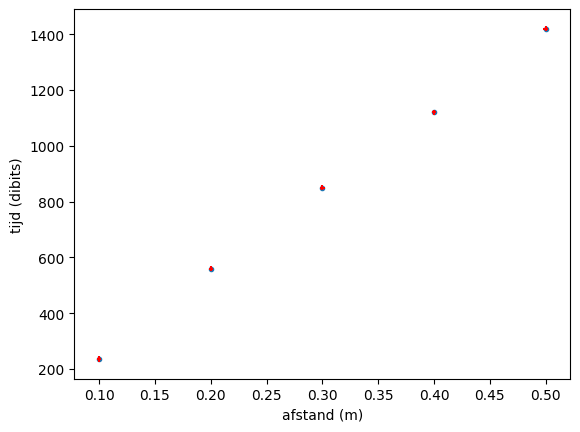

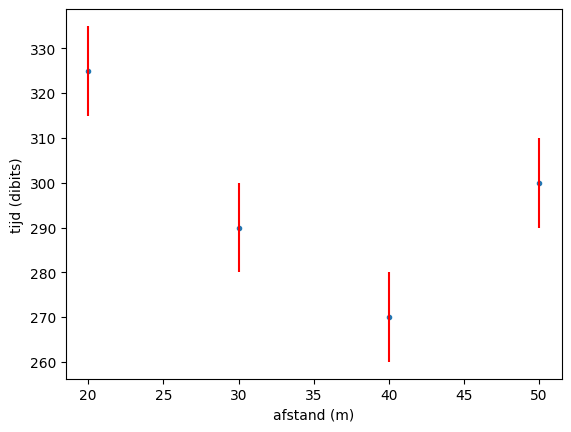

De gemiddelde tijd in dibbits voor een afstand van 10 cm na kalibratie is: 296.25 db
0.03375527426160337
10161.375
Het aantal s in 1 db is: 9.841187831371247e-05 s
a:0.035074764629868804 +/- 0.0004766451087028106
b:0.36366992800466236 +/- 0.49459243224213395


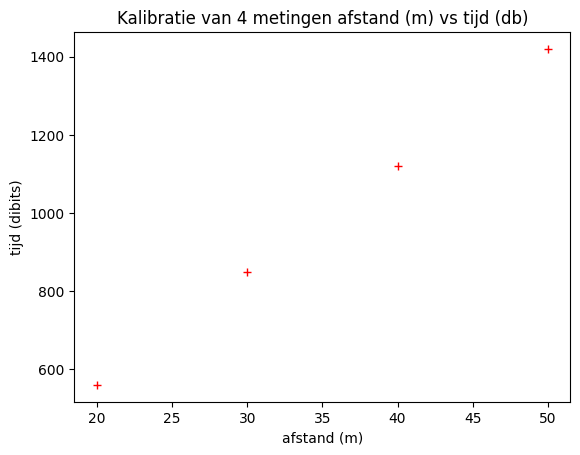

In [ ]:
# verwerk hier jullie kalibratiemetingen
distance_between_src_rcvr = np.array([10,20,30, 40, 50]) / 100    # m
kalibratiemetingen = np.array([235, 560, 850, 1120, 1420 ])      # dibits

k_error = 10  # dibits
distance_error = 2/1000     # m

plt.figure()
plt.errorbar(distance_between_src_rcvr, kalibratiemetingen, 
             xerr=distance_error, yerr=k_error, fmt='.', ecolor='r', barsabove=True)
plt.ylabel('tijd (dibits)')
plt.xlabel('afstand (m)')
plt.show()
# verwijderen meting 1 want onnauwkeurig
meting10 = 235      #db
meting20= 560
meting30= 850
m40=1120
m50 = 1420
kmet2 = np.array([meting20-meting10, meting30- meting20, m40-meting30, m50-m40])        
distance_between_src_rcvr_2 = np.array([20,30,40,50])       # cm
plt.figure()
plt.errorbar(distance_between_src_rcvr_2, kmet2, 
             xerr=distance_error, yerr=k_error, fmt='.', ecolor='r', barsabove=True)
plt.ylabel('tijd (dibits)')
plt.xlabel('afstand (m)')
plt.show()
print ('De gemiddelde tijd in dibbits voor een afstand van 10 cm na kalibratie is:', np.mean(kmet2), 'db')
# berekening hoeveelheid tijd in 1 dibit
speed_sound = 343       # m/s # T=20 g
# dibits per tijd
dib_afstand = 1/ (np.mean(kmet2) /10)      # in 1 m
dib_tijd = speed_sound/dib_afstand
print(dib_afstand)     # aantal m in 1 dibit
print(dib_tijd) # aantal db in 1 s
print('Het aantal s in 1 db is:', 1/dib_tijd, 's')

# curve-fitting
from scipy.optimize import curve_fit

def function(x, a, b):
    return a*x+b

popt, pcov = curve_fit(function, kalibratiemetingen[1:], distance_between_src_rcvr_2)
a,b = popt
u_a = np.sqrt(pcov[0,0])
u_b = np.sqrt(pcov[1,1])
print(f'a:{a} +/- {u_a}')
print(f'b:{b} +/- {u_b}')
# kaLIBRATIE plot
plt.title('Kalibratie van 4 metingen afstand (m) vs tijd (db)')
plt.plot(distance_between_src_rcvr_2, kalibratiemetingen[1:], 'r+')
plt.ylabel('tijd (dibits)')
plt.xlabel('afstand (m)')
plt.show()

## Opdracht 4: Test meeting

Running the imaging algorithm with the following data:
   xs  ys  xr  yr     R
0   0  40   0  30  42.8
1   0  30   0  20  42.7
2  40   0  30   0  43.2
3  30   0  20   0  42.4


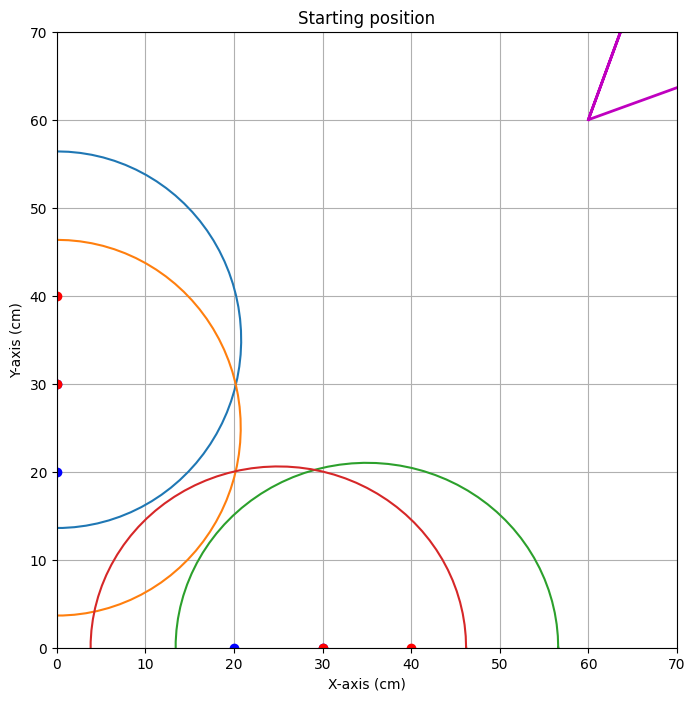


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=99.180


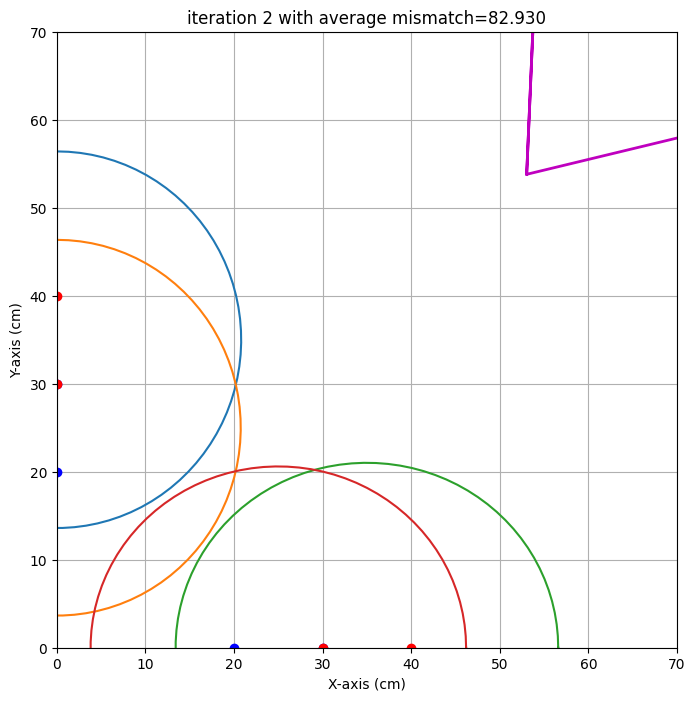

end iteration 2 with average mismatch=82.930


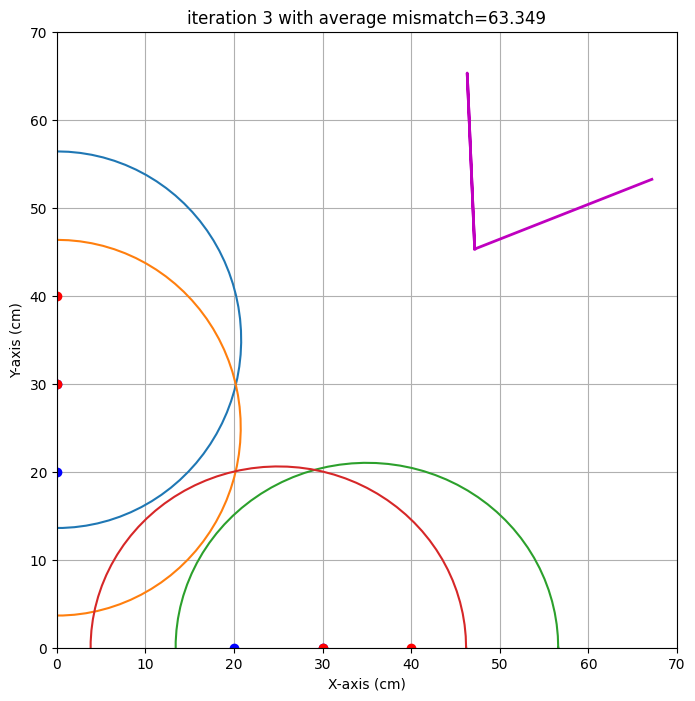

end iteration 3 with average mismatch=63.349


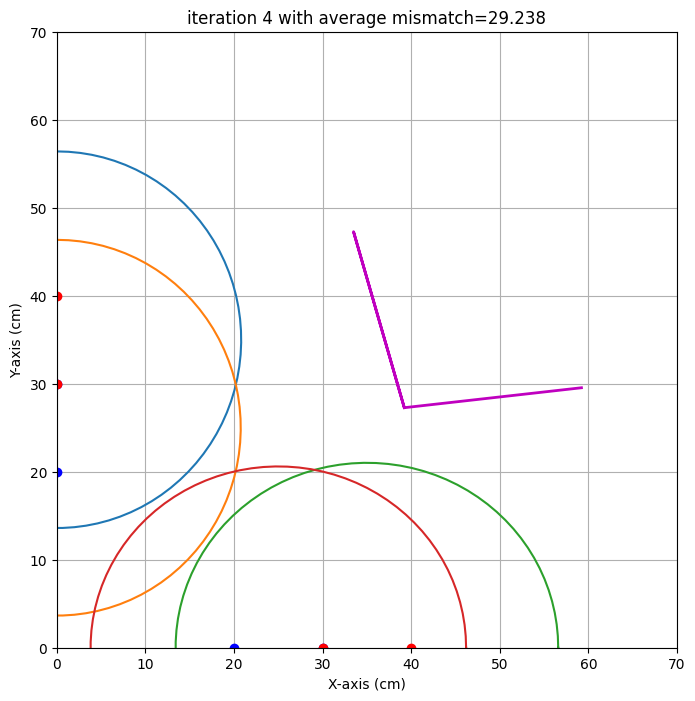

end iteration 4 with average mismatch=29.238


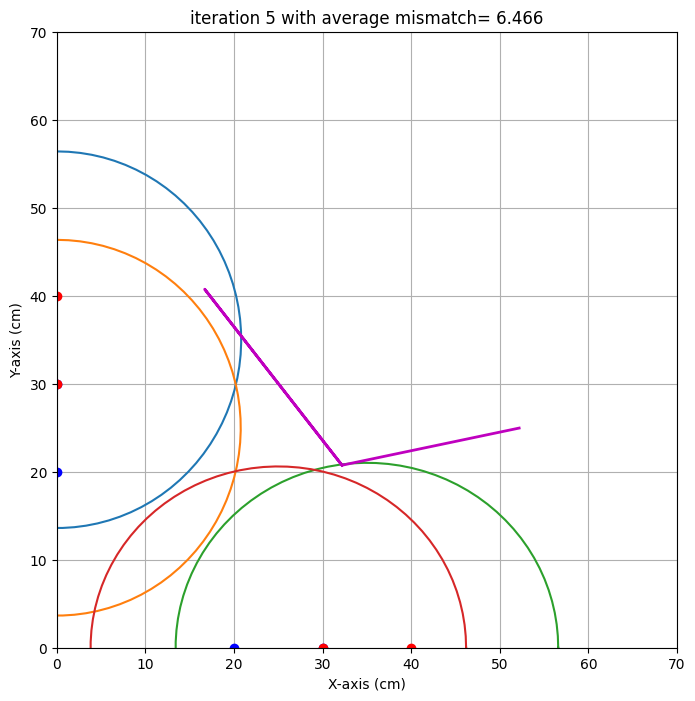

end iteration 5 with average mismatch= 6.466


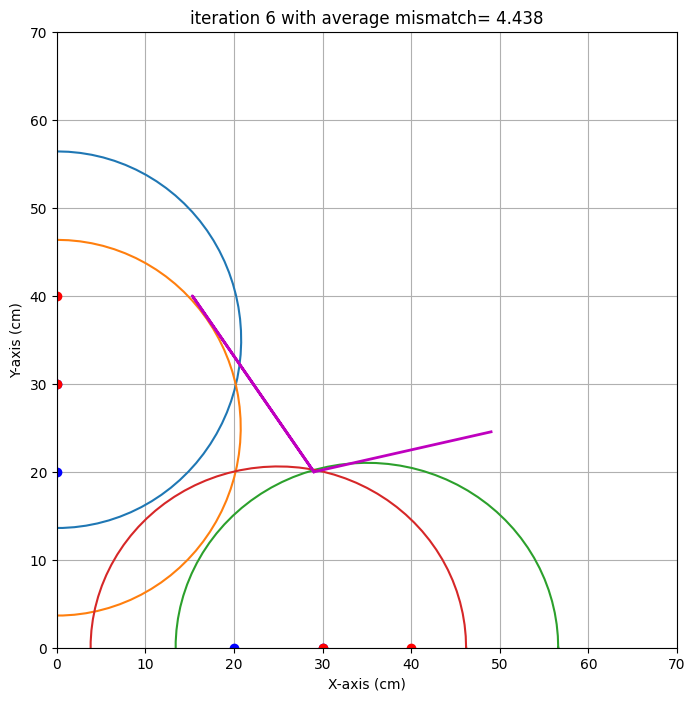

end iteration 6 with average mismatch= 4.438


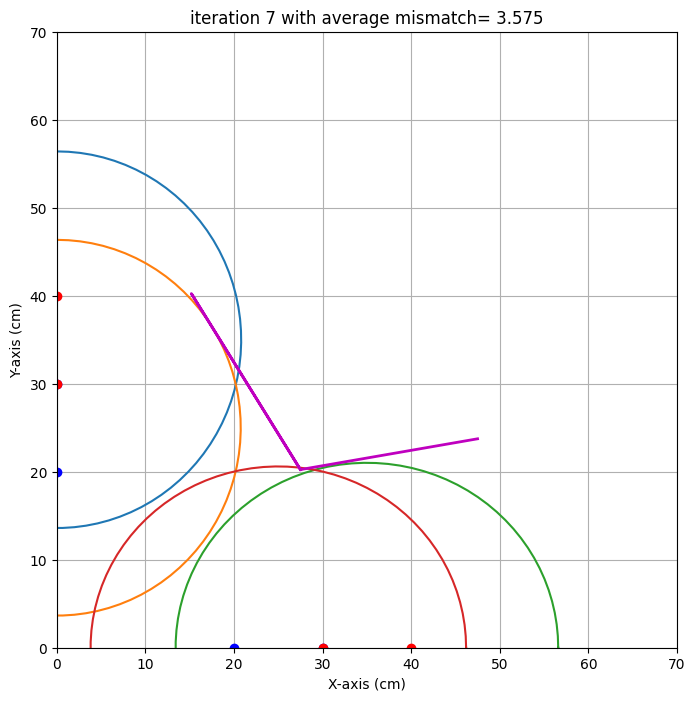

end iteration 7 with average mismatch= 3.575


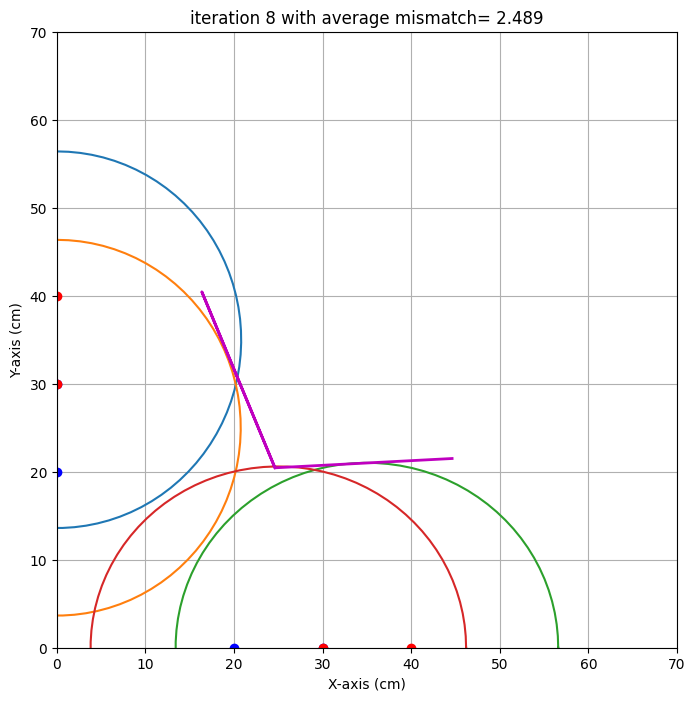

end iteration 8 with average mismatch= 2.489


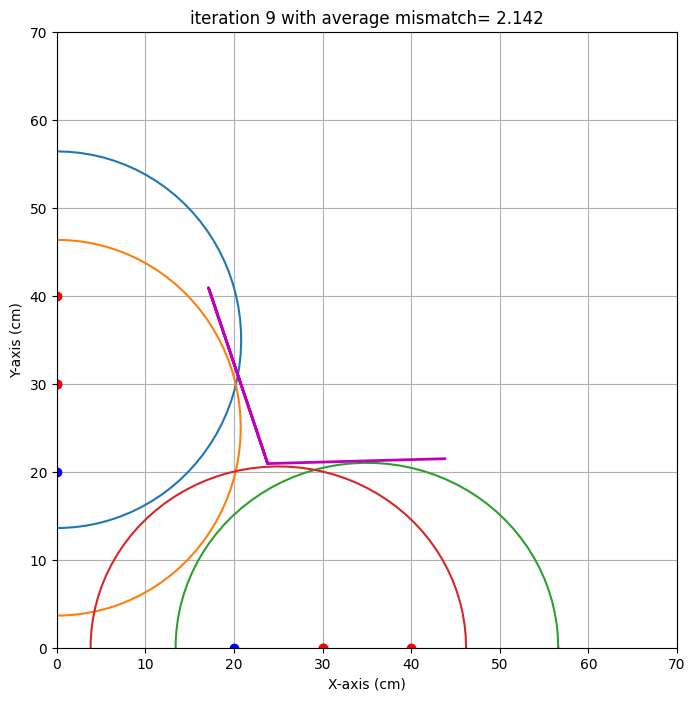

end iteration 9 with average mismatch= 2.142


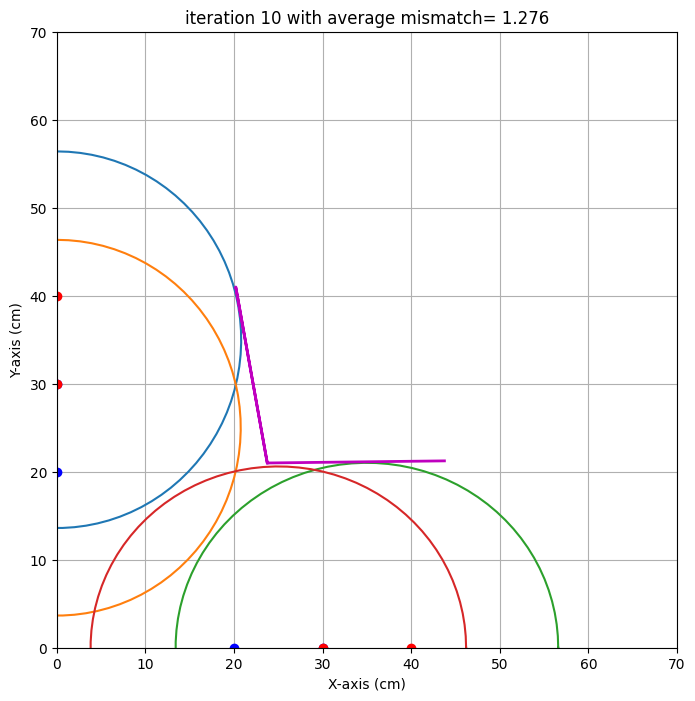

end iteration 10 with average mismatch= 1.276


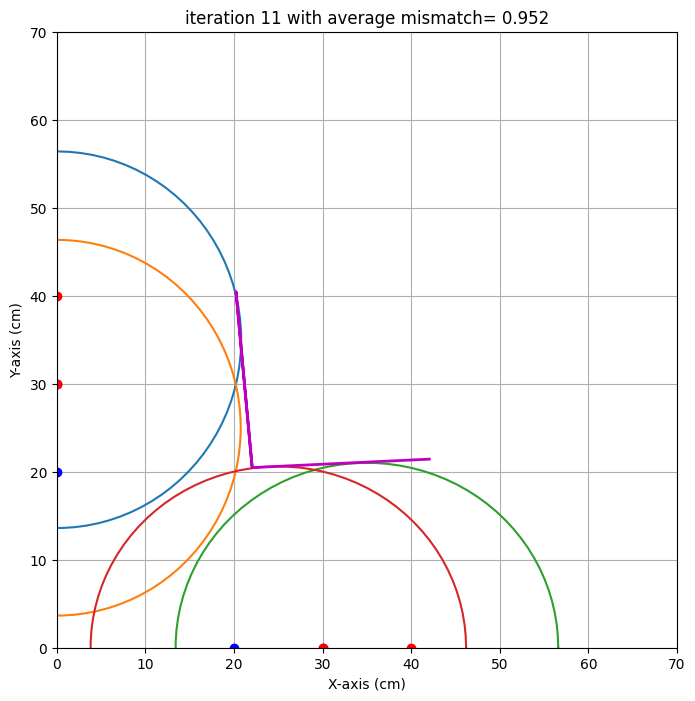

end iteration 11 with average mismatch= 0.952


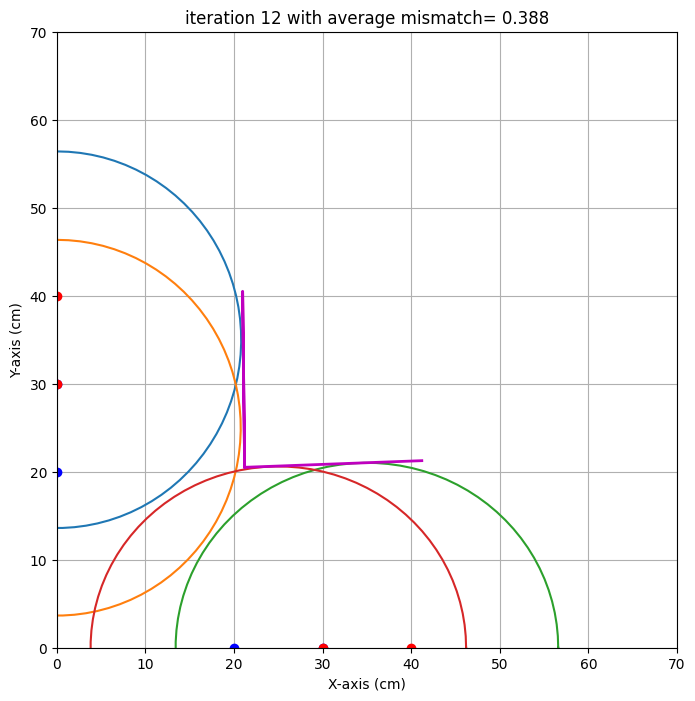

end iteration 12 with average mismatch= 0.388
end iteration 13 with average mismatch= 0.371


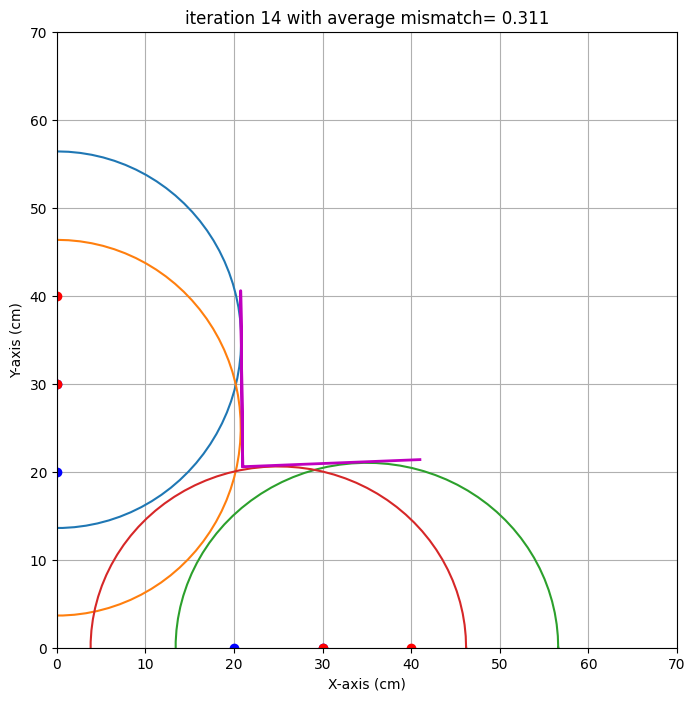

end iteration 14 with average mismatch= 0.311


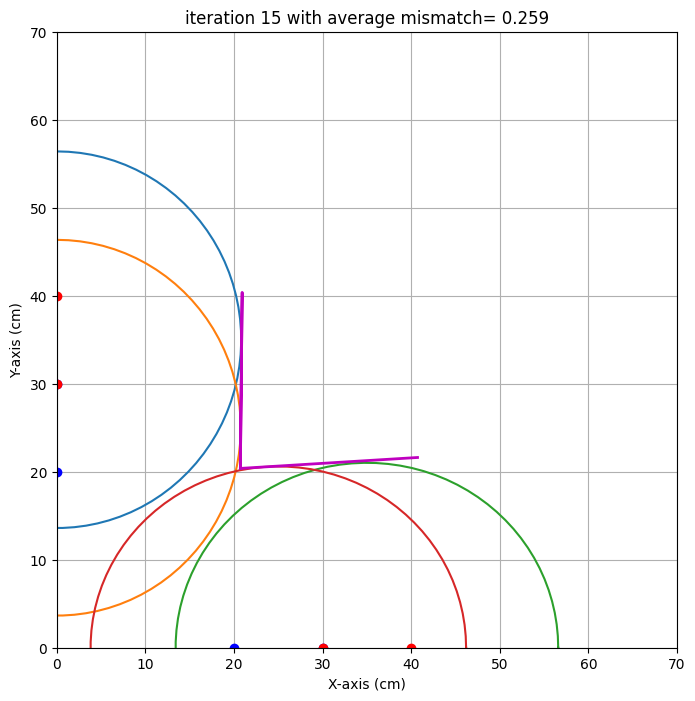

end iteration 15 with average mismatch= 0.259
end iteration 16 with average mismatch= 0.252
end iteration 17 with average mismatch= 0.251
end iteration 18 with average mismatch= 0.251
end iteration 19 with average mismatch= 0.251
end iteration 20 with average mismatch= 0.251
end iteration 21 with average mismatch= 0.251
end iteration 22 with average mismatch= 0.251
end iteration 23 with average mismatch= 0.251
end iteration 24 with average mismatch= 0.251
end iteration 25 with average mismatch= 0.251
end iteration 26 with average mismatch= 0.251
end iteration 27 with average mismatch= 0.251
end iteration 28 with average mismatch= 0.251
end iteration 29 with average mismatch= 0.251
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
wait a little longer....
wait a little longer....
end iteration 30 with average mismatch= 0.251
###############################################################################
end of iteration  30
Best

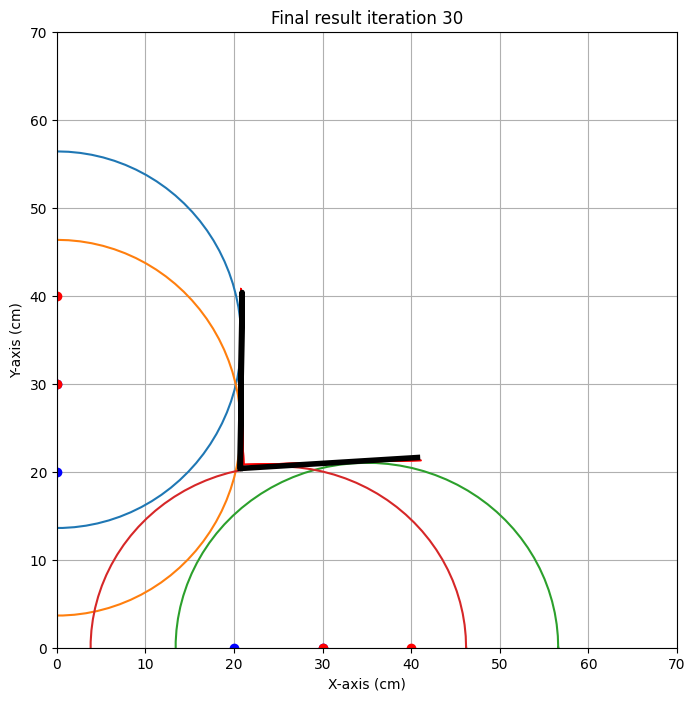

In [47]:
# Vul onderstaande matrixen aan met jullie meetgegevens.
# De getallen 1.0, 2.0, 3.0, 4.0, 5.0, 6.0 en 7.0 moet je door je eigen metingen (in cm!) vervangen.
# Let op dat de meting een totale afstand die het geluid afgelegd heeft moet zijn.

# Als je ongeldige metingen hebt (denk aan het college!), zet ze dan wel in het dataframe hieronder,
# maar gebruik een '#' om de regel uit te commenteren, zoals we bij de laatste meting voorgedaan hebben.

                
dataSanityCheck = pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    [0,40,0,30,42.8],
    [0,30,0,20,42.7],
    #[0,10,0,20,0.36],
    [40,0,30,0,43.2],
    [30,0,20,0,42.4],
    #[10,0,20,0,0.36],
    #[10,0,0,10,0.36]    
    ])

resultaatSanityCheck = imagingDEF.imagingDEF(dataSanityCheck)

In [48]:
# Run deze cel om jullie resultaten te kunnen zien.
txt='x0: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
txt = txt + 'y0: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
txt = txt + 'alpha: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
txt = txt + 'beta: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
print(txt.format(x0=resultaatSanityCheck['x0'],
                 x0_eps=resultaatSanityCheck['x0_eps'],
                 y0=resultaatSanityCheck['y0'],
                 y0_eps=resultaatSanityCheck['y0_eps'],
                 alpha=resultaatSanityCheck['alpha'],
                 alpha_eps=resultaatSanityCheck['alpha_eps'],
                 beta=resultaatSanityCheck['beta'],
                 beta_eps=resultaatSanityCheck['beta_eps']))

x0: 20.7 cm met een standaardafwijking van 0.4 cm 
y0: 20.4 cm met een standaardafwijking van 0.4 cm 
alpha: 3.5 graden met een standaardafwijking van 2.2 graad 
beta: 0.6 graden met een standaardafwijking van 1.5 graad 



## Opdracht 5: Iteratie 0

#### algoritme [naam eerste student]
Voeg een foto in van het algoritme van het eerste groepslid
<img src="tudelftLogo.png" width="400">

#### algoritme [naam tweede student]
Voeg een foto in van het algoritme van het tweede groepslid
<img src="tudelftLogo.png" width="400">

#### algoritme [naam derde student]
Voeg een foto in van het algoritme van het derde groepslid
<img src="tudelftLogo.png" width="400">

In [6]:
# Voeg hier eventueel code toe die je nodig hebt om je algoritme uit te voeren. Dit is optioneel!

## Opdracht 6: Test iteratie 0.

In [7]:
# Voeg hier je meetgegevens van deze iteratie in:

# Vul onderstaande in met jullie gekozen posities van het reflecterende papier
targets = {'x0':,  #zelf aanvullen,
           'y0':#zelf aanvullen,
           'alpha' : #zelf aanvullen,
           'beta' : #zelf aanvullen},
          }
           

# Vul onderstaande matrixen aan met je gemeten meetgegevens. Als je twee algoritmes test, haal dan het hele blok
# bij 'naam3' weg. Zorg natuurlijk dat de arrays en structures netjes afsluiten met ), ] of } op de juiste plekken.

data ={'naam1' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    #zelf aanvullen
    ]),
       'naam2' : pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    #zelf aanvullen
    ]),
       'naam3' : pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    #zelf aanvullen
    ])
      }

SyntaxError: expression expected after dictionary key and ':' (2248694369.py, line 4)

## Opdracht 7: Evaluatie.

In [8]:
# Hier runnen we het imaging algoritme:
resultaat = dict()

for studentName in studentNames:
    print(studentName)
    resultaat[studentName] = imagingDEF.imagingDEF(data[studentName])
    print(resultaat[studentName])

naam1


NameError: name 'data' is not defined

In [9]:
# Run deze cel om jullie resultaten naast elkaar te kunnen zien.
for studentName in studentNames:
    txt='{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = studentName,
                     x0Target=targets['x0'],
                     x0=resultaat[studentName]['x0'],
                     x0_eps=resultaat[studentName]['x0_eps'],
                     y0Target=targets['y0'],
                     y0=resultaat[studentName]['y0'],
                     y0_eps=resultaat[studentName]['y0_eps'],
                     alphaTarget=targets['alpha'],
                     alpha=resultaat[studentName]['alpha'],
                     alpha_eps=resultaat[studentName]['alpha_eps'],
                     betaTarget=targets['beta'],
                     beta=resultaat[studentName]['beta'],
                     beta_eps=resultaat[studentName]['beta_eps']))

NameError: name 'targets' is not defined

## Opdracht 8: Iteratie1+.VERVANG DEZE TEKST DOOR DE TIJD WANNEER JE AAN DEZE ITERATIE BEGINT.
### Synthese
Maak een nieuwe blokkenschema op A3 van wat je nu als algoritme gaat proberen. Als het kleine wijzigingen zijn ten opzichte van een vorige iteratie, kras dan gewoon in de oude blokkenschema als dat duidelijk blijft. Maak een foto en zet die hieronder. Zorg dat het iteratienummer goed op de foto te zien is.

Figuur: ![Alt](tudelftLogo.png)


In [10]:
# Voeg hier eventueel (nieuwe) code toe die je nodig hebt om je algoritme uit te voeren. Dit is optioneel!

## Opdracht 9: Iteratie 1+ meeting en test

In [11]:
# Voeg hier je meetgegevens van deze iteratie in:

# Vul onderstaande in met jullie gekozen locaties van het reflecterende papier.
targets = {'locatie 1':{'x0':#zelf aanvullen,
                    'y0':#zelf aanvullen,
                    'alpha' : #zelf aanvullen,
                    'beta' : #zelf aanvullen},
           'locatie 2':{'x0':#zelf aanvullen,
                    'y0':#zelf aanvullen,
                    'alpha' : #zelf aanvullen,
                    'beta' : #zelf aanvullen}
            }
           

# Vul onderstaande matrixen aan met je gemeten meetgegevens.

data ={'locatie 1' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    # zelf aanvullen
    ]),
       'locatie 2' : pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    # zelf aanvullen
    ])
      }
                        
                        
# Hier runnen we het imaging algoritme:
resultaat = dict()

for locatie in targets:
    print(locatie)
    resultaat[locatie] = imagingDEF.imagingDEF(data[locatie])
    print(resultaat[locatie])

                        
# en hier laten we de resultaten als text zien.
for locatie in targets:
    txt='{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = locatie,
                     x0Target=targets[locatie]['x0'],
                     x0=resultaat[locatie]['x0'],
                     x0_eps=resultaat[locatie]['x0_eps'],
                     y0Target=targets[locatie]['y0'],
                     y0=resultaat[locatie]['y0'],
                     y0_eps=resultaat[locatie]['y0_eps'],
                     alphaTarget=targets[locatie]['alpha'],
                     alpha=resultaat[locatie]['alpha'],
                     alpha_eps=resultaat[locatie]['alpha_eps'],
                     betaTarget=targets[locatie]['beta'],
                     beta=resultaat[locatie]['beta'],
                     beta_eps=resultaat[locatie]['beta_eps']))

SyntaxError: '{' was never closed (3018683157.py, line 4)

## Opdracht 10: Uiteindelijke test met locatie gegeven door TA

In [12]:
# Voeg hier je meetgegevens van de uiteindelijke test in:

# Vul onderstaande in met jullie locaties van het reflecterende papier gegeven
# door jullie TA
targets = {'test locatie':{
                    'x0':  # zelf aanvullen,
                    'y0':  # zelf aanvullen,
                    'alpha' :  # zelf aanvullen,
                    'beta' :  # zelf aanvullen
                          }
            }
           

# Vul onderstaande matrixen aan met je gemeten meetgegevens.

dataFinalCheck ={'test locatie' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
                    # zelf aanvullen
                    ])
                }

# Hier runnen we het imaging algoritme:
resultaat = dict()

for locatie in targets:
    print(locatie)
    resultaat[locatie] = imagingDEF.imagingDEF(dataFinalCheck[locatie])
    print(resultaat[locatie])

    
# Run deze cel om jullie resultaten naast elkaar te kunnen zien.
for locatie in targets:
    txt = '{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = locatie,
                     x0Target=targets[locatie]['x0'],
                     x0=resultaat[locatie]['x0'],
                     x0_eps=resultaat[locatie]['x0_eps'],
                     y0Target=targets[locatie]['y0'],
                     y0=resultaat[locatie]['y0'],
                     y0_eps=resultaat[locatie]['y0_eps'],
                     alphaTarget=targets[locatie]['alpha'],
                     alpha=resultaat[locatie]['alpha'],
                     alpha_eps=resultaat[locatie]['alpha_eps'],
                     betaTarget=targets[locatie]['beta'],
                     beta=resultaat[locatie]['beta'],
                     beta_eps=resultaat[locatie]['beta_eps']))

SyntaxError: invalid syntax (598375666.py, line 7)

## Opdracht 11: Leerdoelen.
Figuur: ![Alt](tudelftLogo.png "Title")

Figuur: ![Alt](tudelftLogo.png "Title")

Figuur: ![Alt](tudelftLogo.png "Title")